Exploratory Data Analysis

In [1]:
!pip install --upgrade numpy

Number of Unique Classes:  22 

Class  0  Symbol:  (
Number of total data points:  14294 

Example Image, Dimensions:  (45, 45)


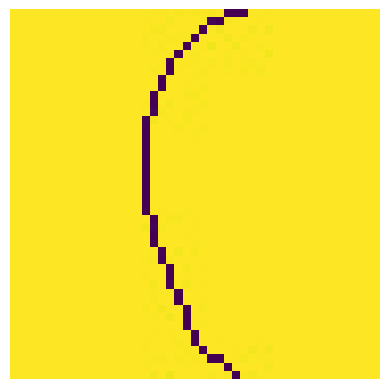

Class  1  Symbol:  )
Number of total data points:  14355 

Example Image, Dimensions:  (45, 45)


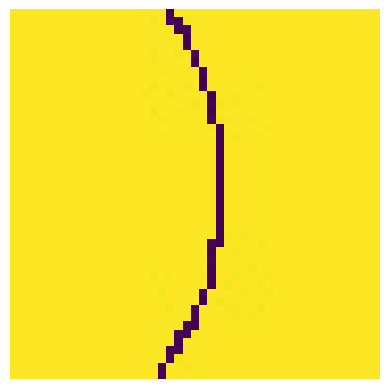

Class  2  Symbol:  +
Number of total data points:  25112 

Example Image, Dimensions:  (45, 45)


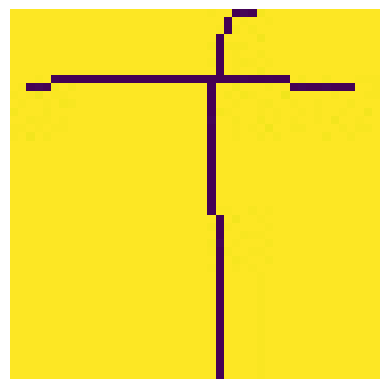

Class  3  Symbol:  -
Number of total data points:  33997 

Example Image, Dimensions:  (45, 45)


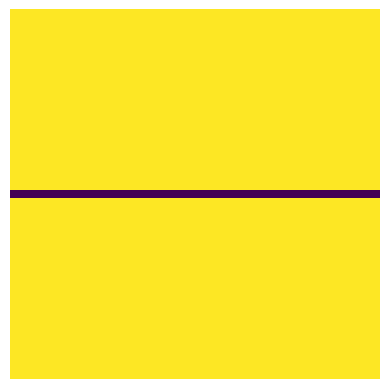

Class  4  Symbol:  0
Number of total data points:  6914 

Example Image, Dimensions:  (45, 45)


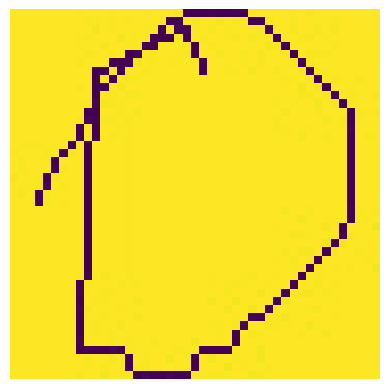

Class  5  Symbol:  1
Number of total data points:  26520 

Example Image, Dimensions:  (45, 45)


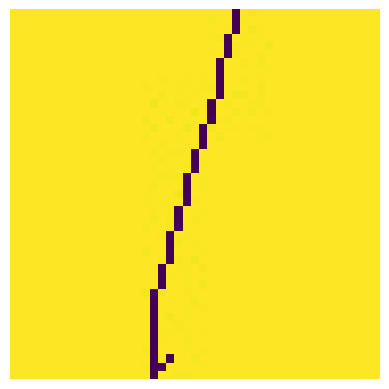

Class  6  Symbol:  2
Number of total data points:  26141 

Example Image, Dimensions:  (45, 45)


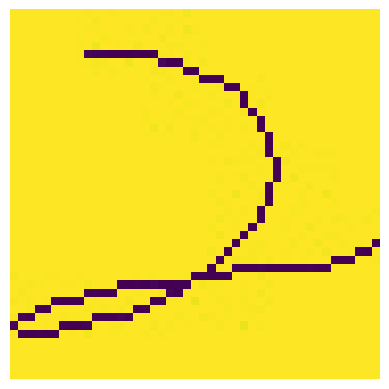

Class  7  Symbol:  3
Number of total data points:  10909 

Example Image, Dimensions:  (45, 45)


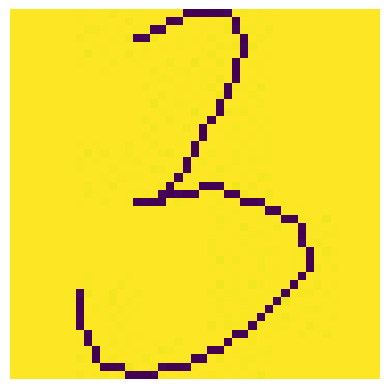

Class  8  Symbol:  4
Number of total data points:  7396 

Example Image, Dimensions:  (45, 45)


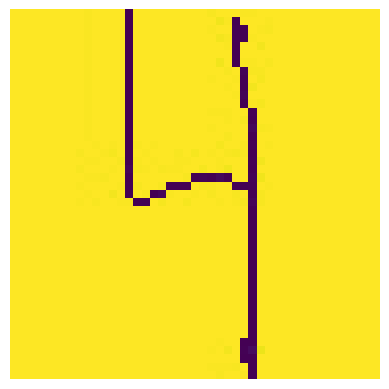

Class  9  Symbol:  5
Number of total data points:  3545 

Example Image, Dimensions:  (45, 45)


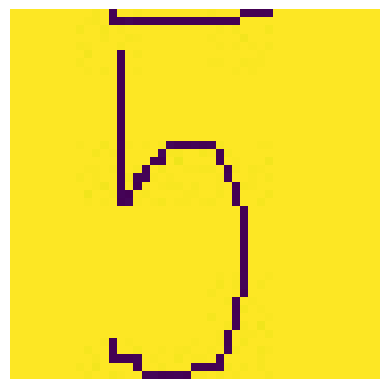

Class  10  Symbol:  6
Number of total data points:  3118 

Example Image, Dimensions:  (45, 45)


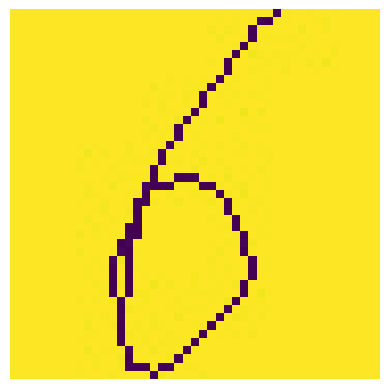

Class  11  Symbol:  7
Number of total data points:  2909 

Example Image, Dimensions:  (45, 45)


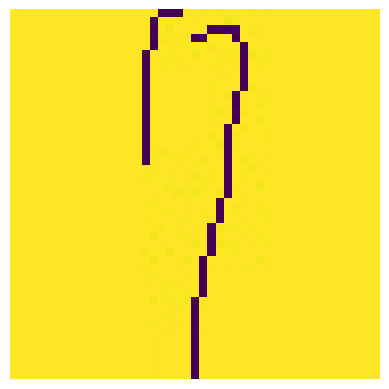

Class  12  Symbol:  8
Number of total data points:  3068 

Example Image, Dimensions:  (45, 45)


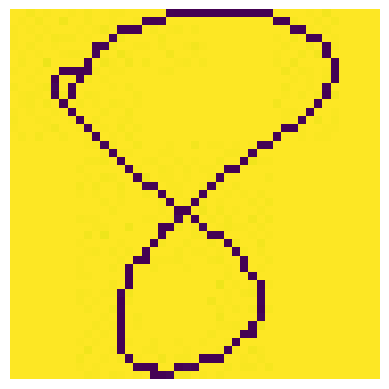

Class  13  Symbol:  9
Number of total data points:  3737 

Example Image, Dimensions:  (45, 45)


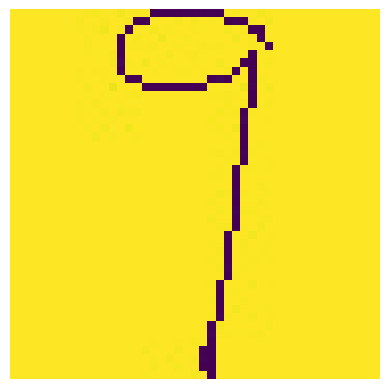

Class  14  Symbol:  =
Number of total data points:  13104 

Example Image, Dimensions:  (45, 45)


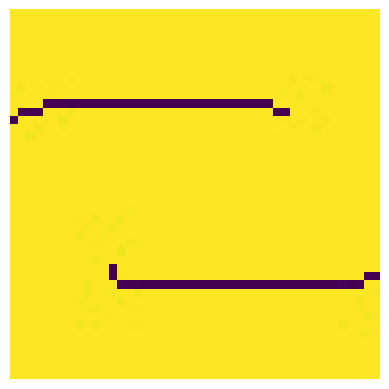

Class  15  Symbol:  div
Number of total data points:  868 

Example Image, Dimensions:  (45, 45)


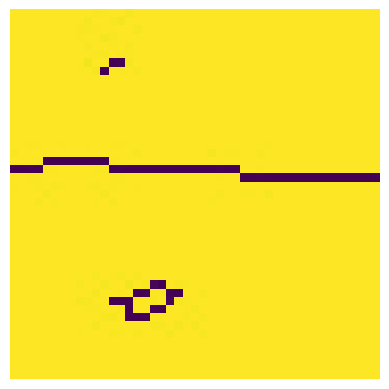

Class  16  Symbol:  f
Number of total data points:  3712 

Example Image, Dimensions:  (45, 45)


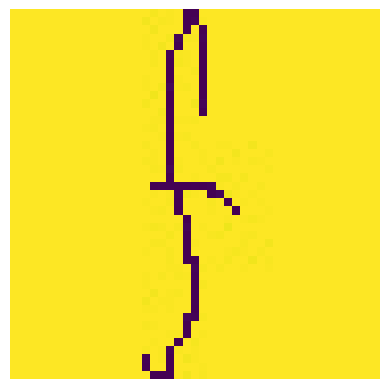

Class  17  Symbol:  forward_slash
Number of total data points:  199 

Example Image, Dimensions:  (45, 45)


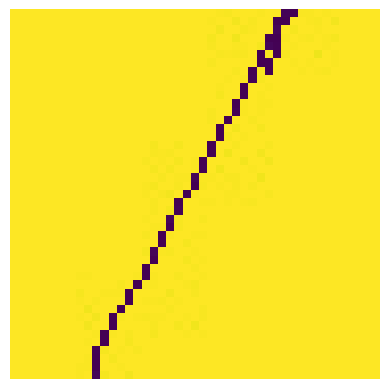

Class  18  Symbol:  neq
Number of total data points:  558 

Example Image, Dimensions:  (45, 45)


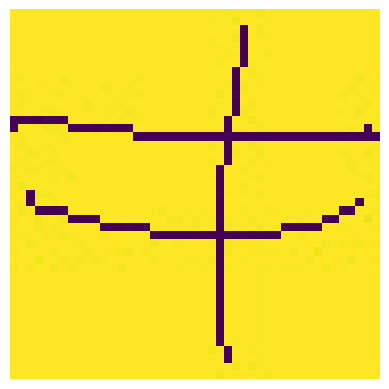

Class  19  Symbol:  times
Number of total data points:  3251 

Example Image, Dimensions:  (45, 45)


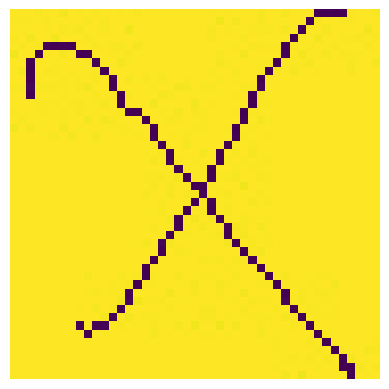

Class  20  Symbol:  X
Number of total data points:  26594 

Example Image, Dimensions:  (45, 45)


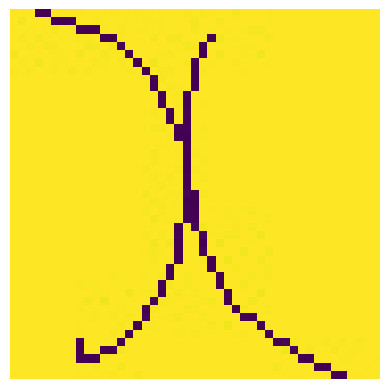

Class  21  Symbol:  y
Number of total data points:  9340 

Example Image, Dimensions:  (45, 45)


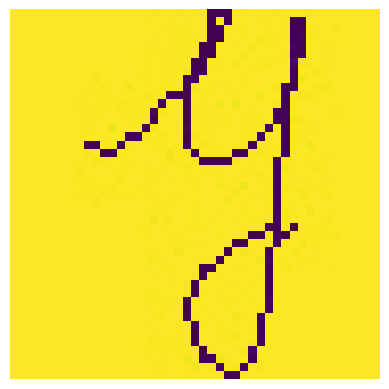

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Number of classes
path = os.path.join("symbols", "extracted_images")
i = 0
class_names = []
class_data_points = []
for root, dirs, files in os.walk(path):
    if i == 0: print("Number of Unique Classes: ", len(dirs), "\n")
    for sub_dir in dirs:
        class_names.append(sub_dir)
        print("Class ", i, " Symbol: ", sub_dir)
        i+=1
        for root2, dirs2, sub_files in os.walk(os.path.join(path, sub_dir)):
            class_data_points.append(len(sub_files))
            print("Number of total data points: ", len(sub_files), "\n")
            
            # Open random image as example
            random_idx = random.randint(0, len(sub_files))
            random_image_name = sub_files[random_idx]
            img = Image.open(os.path.join(root, sub_dir, random_image_name))
            print("Example Image, Dimensions: ", img.size)
            plt.imshow(img)
            plt.axis('off')
            plt.show()


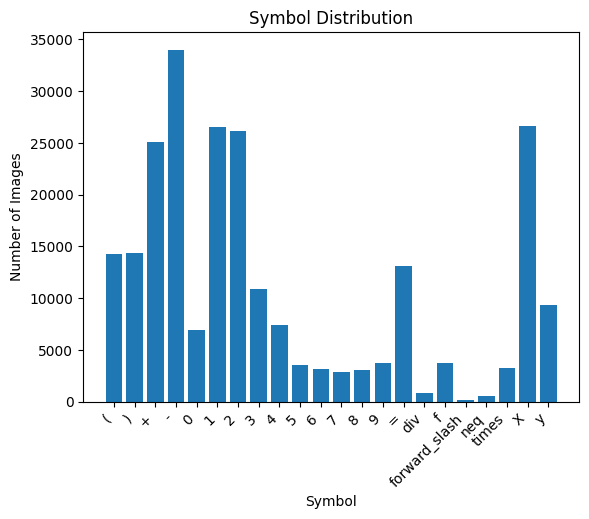

In [6]:
# Class distribution (before fixing)
plt.bar(class_names, class_data_points)
plt.title('Symbol Distribution')
plt.xlabel('Symbol')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Images')
plt.savefig('class_dist.png', bbox_inches='tight')
plt.show() 

# Image Dimensions

# Plot

In [3]:
import os
import random
import shutil

# ===== CONFIG =====
IMAGE_DIR = os.path.join("dataset", "expression_images")
LABEL_DIR = os.path.join("dataset", "expression_labels")

TRAIN_RATIO = 0.8  # 80% train, 20% val
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

# ===== CREATE OUTPUT DIRS =====
for split in ["train", "val"]:
    os.makedirs(os.path.join(IMAGE_DIR, split), exist_ok=True)
    os.makedirs(os.path.join(LABEL_DIR, split), exist_ok=True)

# ===== COLLECT FILES =====
images = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(IMAGE_EXTENSIONS)]
random.shuffle(images)

# ===== SPLIT =====
split_index = int(len(images) * TRAIN_RATIO)
train_files = images[:split_index]
val_files = images[split_index:]

def move_files(file_list, split):
    for img_file in file_list:
        base_name = os.path.splitext(img_file)[0]
        label_file = base_name + "_masked.txt"

        src_img = os.path.join(IMAGE_DIR, img_file)
        src_label = os.path.join(LABEL_DIR, label_file)

        dst_img = os.path.join(IMAGE_DIR, split, img_file)
        dst_label = os.path.join(LABEL_DIR, split, label_file)

        # Move image
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)

        # Move label if exists
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)
        else:
            print(f"Warning: Missing label for {img_file}")

# ===== EXECUTE =====
move_files(train_files, "train")
move_files(val_files, "val")

print(f"Done! {len(train_files)} train and {len(val_files)} val images processed.")

Done! 8000 train and 2000 val images processed.


In [10]:
import os

def normalize_label_name(name):
    # remove "_masked" suffix if present
    if name.endswith("_masked"):
        return name[:-7]  # removes "_masked"
    return name

def check_split(split_path):
    image_dir = os.path.join("dataset", "expression_images", split_path)
    label_dir = os.path.join("dataset", "expression_labels", split_path)

    image_files = [f for f in os.listdir(image_dir)]
    label_files = [f for f in os.listdir(label_dir)]

    image_bases = set(os.path.splitext(f)[0] for f in image_files)
    label_bases = set(
        normalize_label_name(os.path.splitext(f)[0])
        for f in label_files
    )

    missing_labels = image_bases - label_bases
    missing_images = label_bases - image_bases

    print(f"\nChecking: {split_path}")

    if not missing_labels and not missing_images:
        print("✅ All files match!")
    else:
        if missing_labels:
            print(f"❌ Images without labels ({len(missing_labels)}):")
            for f in list(missing_labels)[:10]:
                print("  ", f)

        if missing_images:
            print(f"❌ Labels without images ({len(missing_images)}):")
            for f in list(missing_images)[:10]:
                print("  ", f)


# Run checks
dataset_root = "dataset"

check_split(os.path.join("train"))
check_split(os.path.join("val"))


Checking: train
✅ All files match!

Checking: val
✅ All files match!
